In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import (precision_score, recall_score,
                             average_precision_score,
                             accuracy_score, precision_recall_curve)

In [2]:
RANDOM_SEED = 42
df = pd.read_csv('../data/Synthetic_Financial_datasets_log.csv')

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
test_point = 550
calibration_point = test_point - 50
validation_point = calibration_point - 100

development = df[df['step'] <= test_point].copy()
test = df[df['step'] > test_point].copy()

calibration = df[(df['step'] <= test_point) & (df['step'] > calibration_point)].copy()
validation = df[(df['step'] <= calibration_point) & (df['step'] > validation_point)].copy()

train = df[df['step'] <= validation_point].copy()


splits = {
    "train": train,
    "validation": validation,
    "calibration": calibration,
    "test": test,
}

splits = {
    "train": train,
    "validation": validation,
    "calibration": calibration,
    "test": test,
}

total_positive = df["isFraud"].sum()

print(
    f"{'Split':<12}"
    f"{'Rows':>12}"
    f"{'% dataset':>12}"
    f"{'Frauds':>12}"
    f"{'% frauds':>12}"
    f"{'Fraud rate':>14}"
)

print("-" * 74)

for name, data in splits.items():
    rows = len(data)
    frauds = data["isFraud"].sum()

    dataset_share = rows / len(df) * 100
    fraud_share = frauds / total_positive * 100
    fraud_rate = frauds / rows * 100

    print(
        f"{name:<12}"
        f"{rows:>12,}"
        f"{dataset_share:>11.2f}%"
        f"{frauds:>12,}"
        f"{fraud_share:>11.2f}%"
        f"{fraud_rate:>13.4f}%"
    )

Split               Rows   % dataset      Frauds    % frauds    Fraud rate
--------------------------------------------------------------------------
train          5,787,030      90.95%       4,477      54.51%       0.0774%
validation       274,777       4.32%       1,084      13.20%       0.3945%
calibration      104,212       1.64%         504       6.14%       0.4836%
test             196,601       3.09%       2,148      26.15%       1.0926%


In [5]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
X_train, y_train = train.drop('isFraud', axis=1), train['isFraud']
X_val, y_val = validation.drop('isFraud', axis=1), validation['isFraud']
X_cal, y_cal = calibration.drop('isFraud', axis=1), calibration['isFraud']
X_test, y_test = test.drop('isFraud', axis=1), test['isFraud']

In [7]:
# Baseline 1 - isFlaggedFraud
isFlaggedFraud_precision = precision_score(y_val, X_val['isFlaggedFraud'])
isFlaggedFraud_recall = recall_score(y_val, X_val['isFlaggedFraud'])
isFlaggedFraud_accuracy = accuracy_score(y_val, X_val['isFlaggedFraud'])

print(f"{'isFlaggedFraud feature precision':35}: {isFlaggedFraud_precision:.4f}")
print(f"{'isFlaggedFraud feature recall':35}: {isFlaggedFraud_recall:.4f}")
print(f"{'isFlaggedFraud feature accuracy':35}: {isFlaggedFraud_accuracy:.4f}")

isFlaggedFraud feature precision   : 1.0000
isFlaggedFraud feature recall      : 0.0018
isFlaggedFraud feature accuracy    : 0.9961


In [8]:
# Baseline 2 - DummyClassifier
dummy = DummyClassifier(strategy='prior')
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_val)

dummy_precision = precision_score(y_val, dummy_pred, zero_division=0)
dummy_recall = recall_score(y_val, dummy_pred, zero_division=0)
dummy_accuracy = accuracy_score(y_val, dummy_pred)

print(f"{'Dummy precision':20}: {dummy_precision:.4f}")
print(f"{'Dummy recall':20}: {dummy_recall:.4f}")
print(f"{'Dummy accuracy':20}: {dummy_accuracy:.4f}")

Dummy precision     : 0.0000
Dummy recall        : 0.0000
Dummy accuracy      : 0.9961


In [9]:
# Baseline 3 - Logistic Regression
features = ['step', 'type', 'amount']

preprocessor = ColumnTransformer(transformers=[
    ('numeric', StandardScaler(), ['step', 'amount']),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), ['type'])
])

logreg_base = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(class_weight=None,
                                 random_state=RANDOM_SEED))
])

logreg_balanced = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(class_weight='balanced',
                                 random_state=RANDOM_SEED))
])

In [15]:
logreg_base.fit(X_train[features], y_train)
logreg_base_pred = logreg_base.predict(X_val)
logreg_base_proba = logreg_base.predict_proba(X_val)[:, 1]

logreg_base_precision = precision_score(y_val, logreg_base_pred, zero_division=0)
logreg_base_recall = recall_score(y_val, logreg_base_pred, zero_division=0)
logreg_base_accuracy = accuracy_score(y_val, logreg_base_pred)
logreg_base_pr = average_precision_score(y_val, logreg_base_proba)

print(f"{'Logreg unbalanced precision':20}: {logreg_base_precision:.4f}")
print(f"{'Logreg unbalanced recall':20}: {logreg_base_recall:.4f}")
print(f"{'Logreg unbalanced accuracy':20}: {logreg_base_accuracy:.4f}")
print(f"{'Logreg unbalanced PR':20}: {logreg_base_pr:.4f}")

precision_log_unbalanced, recall_log_unbalanced, _ = precision_recall_curve(
    y_val,
    logreg_base_proba
)

Logreg unbalanced precision: 0.0000
Logreg unbalanced recall: 0.0000
Logreg unbalanced accuracy: 0.9961
Logreg unbalanced PR: 0.0604


In [16]:
logreg_balanced.fit(X_train[features], y_train)
logreg_balanced_pred = logreg_balanced.predict(X_val)
logreg_balanced_proba = logreg_balanced.predict_proba(X_val)[:, 1]

logreg_balanced_precision = precision_score(y_val, logreg_balanced_pred, zero_division=0)
logreg_balanced_recall = recall_score(y_val, logreg_balanced_pred, zero_division=0)
logreg_balanced_accuracy = accuracy_score(y_val, logreg_balanced_pred)
logreg_balanced_pr = average_precision_score(y_val, logreg_balanced_proba)

print(f"{'Logreg balanced precision':20}: {logreg_balanced_precision:.4f}")
print(f"{'Logreg balanced recall':20}: {logreg_balanced_recall:.4f}")
print(f"{'Logreg balanced accuracy':20}: {logreg_balanced_accuracy:.4f}")
print(f"{'Logreg balanced PR':20}: {logreg_balanced_pr:.4f}")

precision_log_balanced, recall_log_balanced, _ = precision_recall_curve(
    y_val,
    logreg_balanced_proba
)

Logreg balanced precision: 0.0326
Logreg balanced recall: 0.7334
Logreg balanced accuracy: 0.9131
Logreg balanced PR  : 0.1075


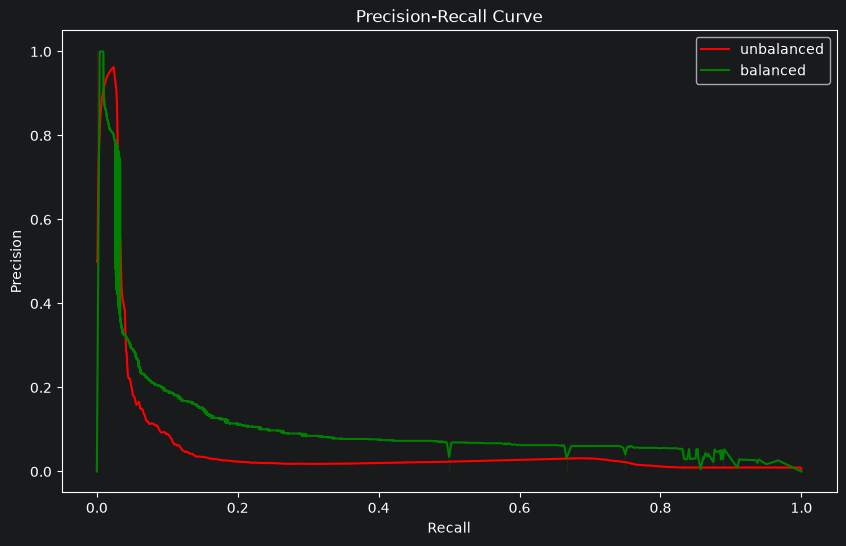

In [17]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    x=recall_log_unbalanced,
    y=precision_log_unbalanced,
    color='red',
    label='unbalanced'
)
sns.lineplot(
    x=precision_log_balanced,
    y=recall_log_balanced,
    color='green',
    label='balanced'
)
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

In [12]:
pd.DataFrame({
    'Model': ['isFlaggedFraud', 'Dummy', 'Logreg unbalanced', 'Logreg balanced'],
    'Precision': [isFlaggedFraud_precision, dummy_precision, logreg_base_precision, logreg_balanced_precision],
    'Recall': [isFlaggedFraud_recall, dummy_recall, logreg_base_recall, logreg_balanced_recall],
    'PR': ['-', '-', round(logreg_base_pr,3), round(logreg_balanced_pr,3)]
}).round(3)

,Model,Precision,Recall,PR
0,isFlaggedFraud,1.000,0.002,-
1,Dummy,0.000,0.000,-
2,Logreg unbalanced,0.000,0.000,0.06
3,Logreg balanced,0.033,0.733,0.107
